In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Import regular expressions for extracting numbers

path_to_scenarios = '/home/abhis/india_power/scenarios'
scenario_names = ['ra_2050_1'] 
print(f"Processing scenarios: {scenario_names}")
path_to_images    = '/home/abhis/india_power/images'
# path_to_csvs      = '/home/abhis/india_power/gridpath_india_viz/csvs'

all_load_data = []

for scenario_name in scenario_names:
    scenario_path = os.path.join(path_to_scenarios, scenario_name)

    # Iterate through weather iterations
    for weather_folder in os.listdir(scenario_path):
        if weather_folder.startswith('weather_iteration_'):
            weather_match = re.search(r'\d+', weather_folder)
            if not weather_match:
                continue
            weather_iteration = int(weather_match.group())
            weather_path = os.path.join(scenario_path, weather_folder)
            if not os.path.isdir(weather_path):
                continue

            # Iterate through hydro iterations
            for hydro_folder in os.listdir(weather_path):
                if hydro_folder.startswith('hydro_iteration_'):
                    hydro_match = re.search(r'\d+', hydro_folder)
                    if not hydro_match:
                        continue
                    hydro_iteration = int(hydro_match.group())
                    hydro_path = os.path.join(weather_path, hydro_folder)
                    if not os.path.isdir(hydro_path):
                        continue

                    # Iterate through availability iterations
                    for avail_folder in os.listdir(hydro_path):
                        if avail_folder.startswith('availability_iteration_'):
                            avail_match = re.search(r'\d+', avail_folder)
                            if not avail_match:
                                continue
                            availability_iteration = int(avail_match.group())
                            avail_path = os.path.join(hydro_path, avail_folder)
                            if not os.path.isdir(avail_path):
                                continue

                            # Construct path to load_mw.tab
                            load_tab_path = os.path.join(avail_path, 'inputs', 'load_mw.tab') # Corrected filename

                            if os.path.exists(load_tab_path):
                                try:
                                    # Read the load_mw.tab file
                                    df_load = pd.read_csv(load_tab_path, sep='\t')

                                    # Add iteration columns
                                    # df_load['scenario_name'] = scenario_name # Removed scenario_name
                                    df_load['weather_iteration'] = weather_iteration
                                    df_load['hydro_iteration'] = hydro_iteration
                                    df_load['availability_iteration'] = availability_iteration

                                    # Reorder columns to put iteration columns first
                                    iteration_cols = ['weather_iteration', 'hydro_iteration', 'availability_iteration'] # Removed scenario_name
                                    original_cols = [col for col in df_load.columns if col not in iteration_cols]
                                    df_load = df_load[iteration_cols + original_cols]

                                    all_load_data.append(df_load)
                                except Exception as e:
                                    print(f"Error reading {load_tab_path}: {e}")
                            else:
                                print(f"Warning: load_mw.tab not found in {os.path.join(avail_path, 'inputs')}") # Corrected filename in warning

# Concatenate all dataframes
if all_load_data:
    final_load_df = pd.concat(all_load_data, ignore_index=True)
    print("Combined DataFrame created successfully.")
    
    # --- Add timestamp column --- 
    try:
        # Ensure timepoint is string
        final_load_df['timepoint_str'] = final_load_df['timepoint'].astype(str)
        # Extract date and hour parts
        final_load_df['date_str'] = final_load_df['timepoint_str'].str[:8]
        final_load_df['hour_str'] = final_load_df['timepoint_str'].str[8:]
        # Convert hour (assuming HE 01-24) to 0-23 index
        final_load_df['hour_int'] = final_load_df['hour_str'].astype(int) - 1
        # Create timestamp objects
        final_load_df['timestamp'] = pd.to_datetime(final_load_df['date_str'], format='%Y%m%d') + pd.to_timedelta(final_load_df['hour_int'], unit='h')
        # Drop temporary columns
        final_load_df = final_load_df.drop(columns=['timepoint_str', 'date_str', 'hour_str', 'hour_int'])
        print("Timestamp column added successfully to final_load_df.")
        
        # --- Reorder columns to put timestamp first --- 
        cols = list(final_load_df.columns)
        # Remove timestamp from list and insert at the beginning
        cols.insert(0, cols.pop(cols.index('timestamp')))
        final_load_df = final_load_df[cols]
        print("Columns reordered with timestamp first.")
        # ---------------------------------------------
    except Exception as e:
        print(f"Error creating or reordering timestamp column: {e}")
    # -----------------------------
    
    # Display the first few rows (optional)
    # print(final_load_df.head())
else:
    print("No load_mw.tab files were found or processed.") # Corrected filename in message
    

Processing scenarios: ['ra_2050_1']
Combined DataFrame created successfully.
Timestamp column added successfully to final_load_df.
Columns reordered with timestamp first.


In [2]:
# Define the path to save the CSV
path_to_csvs = '/home/abhis/india_power/gridpath_india_viz/csvs'

# Check if final_load_df exists and is not empty
if 'final_load_df' in locals() and not final_load_df.empty:
    # Create the directory if it doesn't exist
    os.makedirs(path_to_csvs, exist_ok=True)
    
    # Define the filename
    csv_filename = os.path.join(path_to_csvs, 'final_load_data.csv')
    
    try:
        # Save the DataFrame to CSV
        final_load_df.to_csv(csv_filename, index=False)
        print(f"DataFrame saved successfully to {csv_filename}")
    except Exception as e:
        print(f"Error saving DataFrame to CSV: {e}")
else:
    print("final_load_df not found or is empty. Cannot save to CSV. Run the previous cell first.")

DataFrame saved successfully to /home/abhis/india_power/gridpath_india_viz/csvs/final_load_data.csv


In [3]:

# Define the load zone to aggregate. Use 'national' for all zones.
selected_load_zone = 'Goa' # Options: 'national' or a specific load_zone name (e.g., 'Goa')

# Check if final_load_df exists and is not empty
if 'final_load_df' in locals() and not final_load_df.empty:
    if selected_load_zone.lower() == 'national':
        print(f"Aggregating load for: National")
        # --- Aggregate for National --- 
        # Define the columns to group by (timestamp, iterations, original timepoint)
        grouping_cols = ['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration', 'timepoint']
        
        # Group by the defined columns and sum the 'load_mw' across original load zones
        aggregated_load_df = final_load_df.groupby(grouping_cols, as_index=False)['load_mw'].sum()
        
        # Add the 'load_zone' column with 'national' value
        aggregated_load_df['load_zone'] = 'national'
        
        # Reorder columns: timestamp first, then iterations, timepoint, load_zone, load_mw
        final_cols_order = grouping_cols + ['load_zone', 'load_mw']
        aggregated_load_df = aggregated_load_df[final_cols_order]
        print("National aggregated load DataFrame created successfully.")
        # ----------------------------- 
    else:
        print(f"Filtering load for: {selected_load_zone}")
        # --- Filter for a specific load zone --- 
        if 'LOAD_ZONES' in final_load_df.columns: # Corrected column name
            aggregated_load_df = final_load_df[final_load_df['LOAD_ZONES'] == selected_load_zone].copy() # Corrected column name
            if aggregated_load_df.empty:
                print(f"Warning: No data found for load zone '{selected_load_zone}'. Check spelling and data.")
            else:
                print(f"Filtered DataFrame for load zone '{selected_load_zone}' created successfully.")
                # Ensure column order is consistent (optional, but good practice)
                # Define expected columns (adjust if final_load_df structure varies)
                expected_cols = ['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration', 'LOAD_ZONES', 'timepoint', 'load_mw'] # Corrected column name
                # Filter out any columns not present in the dataframe
                existing_cols = [col for col in expected_cols if col in aggregated_load_df.columns]
                aggregated_load_df = aggregated_load_df[existing_cols]
        else:
            print("Error: 'LOAD_ZONES' column not found in final_load_df. Cannot filter by specific zone.") # Corrected column name in error message
            aggregated_load_df = pd.DataFrame() # Create empty df to avoid errors later
        # ------------------------------------ 
    
    # Assign to the expected variable name for the next cell
    national_load_df = aggregated_load_df 
    
    # Display the first few rows (optional)
    # if not national_load_df.empty:
    #     print(national_load_df.head())
else:
    print("final_load_df not found or is empty. Run the previous cell first.")
    national_load_df = pd.DataFrame() # Ensure variable exists even if previous cell failed

Filtering load for: Goa
Filtered DataFrame for load zone 'Goa' created successfully.


Plotting 4 iteration combinations.


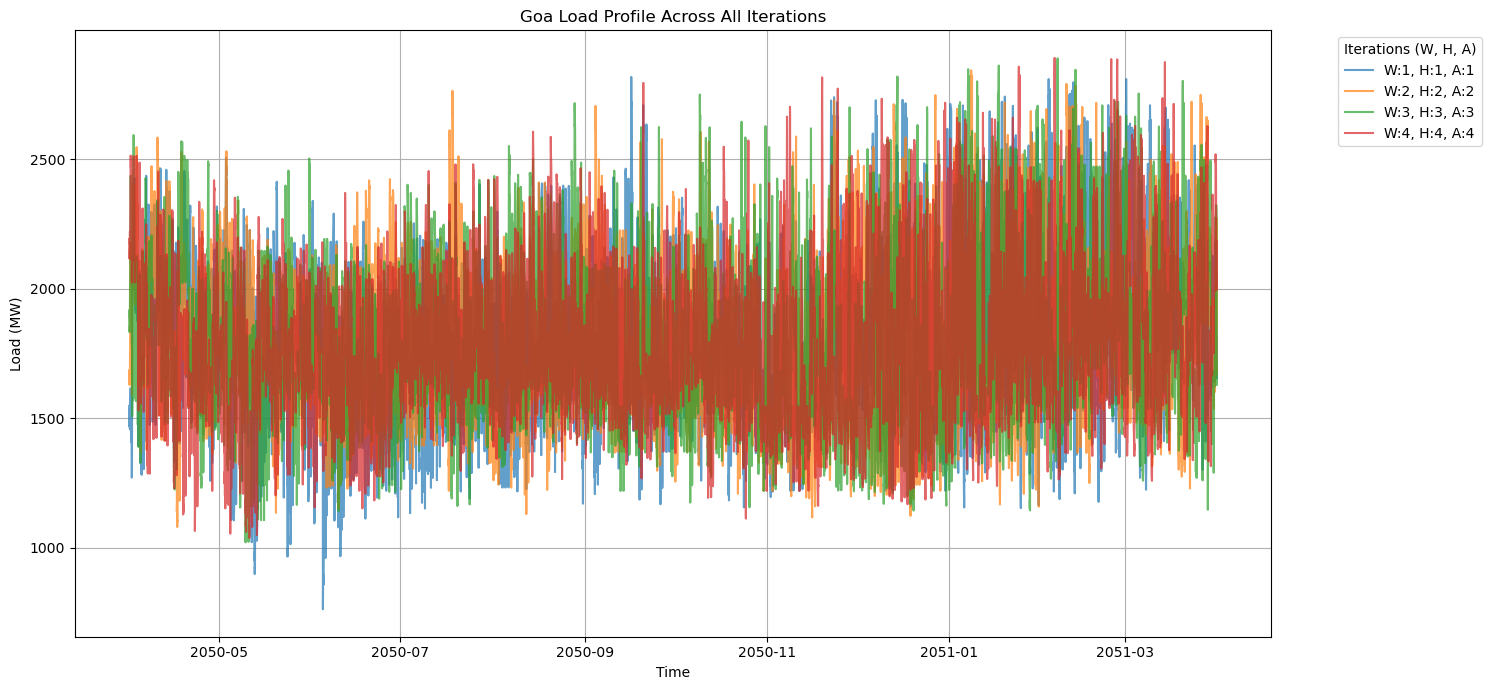

Plot saved to /home/abhis/india_power/images/national_load_profile.png


<Figure size 640x480 with 0 Axes>

In [4]:
# plot load_mw for each combination of weather_iteration, hydro_iteration, availability_iteration

# Check if national_load_df exists and is not empty
if 'national_load_df' in locals() and not national_load_df.empty:
    # Use the timestamp column for the x-axis
    x_axis_col = 'timestamp'
    x_label = 'Time'
    temp_df = national_load_df.copy() # Work on a copy 
        
    plt.figure(figsize=(15, 7)) # Adjust figure size as needed

    # Iterate through unique iteration combinations
    iteration_groups = temp_df.groupby(['weather_iteration', 'hydro_iteration', 'availability_iteration'])

    print(f"Plotting {len(iteration_groups)} iteration combinations.")

    for name, group in iteration_groups:
        weather_iter, hydro_iter, avail_iter = name
        label = f"W:{weather_iter}, H:{hydro_iter}, A:{avail_iter}"
        # Sort by the x-axis column before plotting to ensure lines connect correctly
        group = group.sort_values(x_axis_col)
        plt.plot(group[x_axis_col], group['load_mw'], label=label, alpha=0.7) # Plot using timestamp

    plt.title(f'{selected_load_zone} Load Profile Across All Iterations')
    plt.xlabel(x_label) # Use dynamic x-label
    plt.ylabel('Load (MW)')
    
    # Only show legend if number of combinations is manageable (e.g., < 20)
    if len(iteration_groups) < 20:
         plt.legend(title="Iterations (W, H, A)", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
         print(f"Skipping legend due to large number of combinations ({len(iteration_groups)}).")
         
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

else:
    print("national_load_df not found or is empty. Run the previous cells first.")
#

#save the plot to path_to_images    = '/home/abhis/india_power/images'
if 'national_load_df' in locals() and not national_load_df.empty:
    # Save the plot to the specified path
    plot_filename = os.path.join(path_to_images, 'national_load_profile.png')
    plt.savefig(plot_filename, bbox_inches='tight') # Save with tight layout
    print(f"Plot saved to {plot_filename}")
else:
    print("national_load_df not found or is empty. Run the previous cells first.")

Box plot saved to /home/abhis/india_power/images/Goa_load_boxplot_weather.png


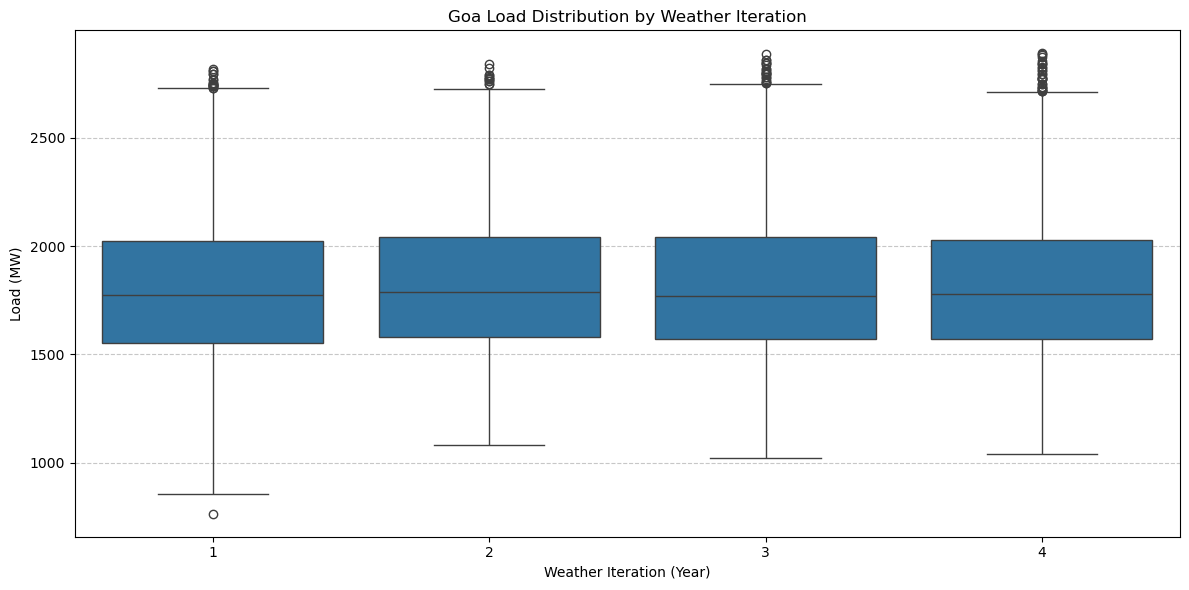

In [5]:
# Create a box plot: Weather Iteration vs Load (MW)

# Check if national_load_df exists and is not empty
if 'national_load_df' in locals() and not national_load_df.empty:
    plt.figure(figsize=(12, 6)) # Adjust figure size
    sns.boxplot(data=national_load_df, x='weather_iteration', y='load_mw')
    plt.xlabel('Weather Iteration (Year)')
    plt.ylabel('Load (MW)')
    plt.title(f'{selected_load_zone} Load Distribution by Weather Iteration')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the box plot
    boxplot_filename = os.path.join(path_to_images, f'{selected_load_zone}_load_boxplot_weather.png')
    plt.savefig(boxplot_filename, bbox_inches='tight')
    print(f"Box plot saved to {boxplot_filename}")
    plt.show()
else:
    print("national_load_df not found or is empty. Cannot create box plot. Run the previous cells first.")
